Using M2 GPU (MPS)
🚀 Initializing Willow Creek Climate Engine on: mps
📊 Processing Climate Data...
🧠 Training Model for 100 Epochs...


Training Progress:   0%|          | 0/100 [00:00<?, ?it/s]

🔮 Generating Probabilistic Forecast...


Simulating 2013 Projections:   0%|          | 0/30 [00:00<?, ?it/s]

🎨 Finalizing Plots and Saving Data...


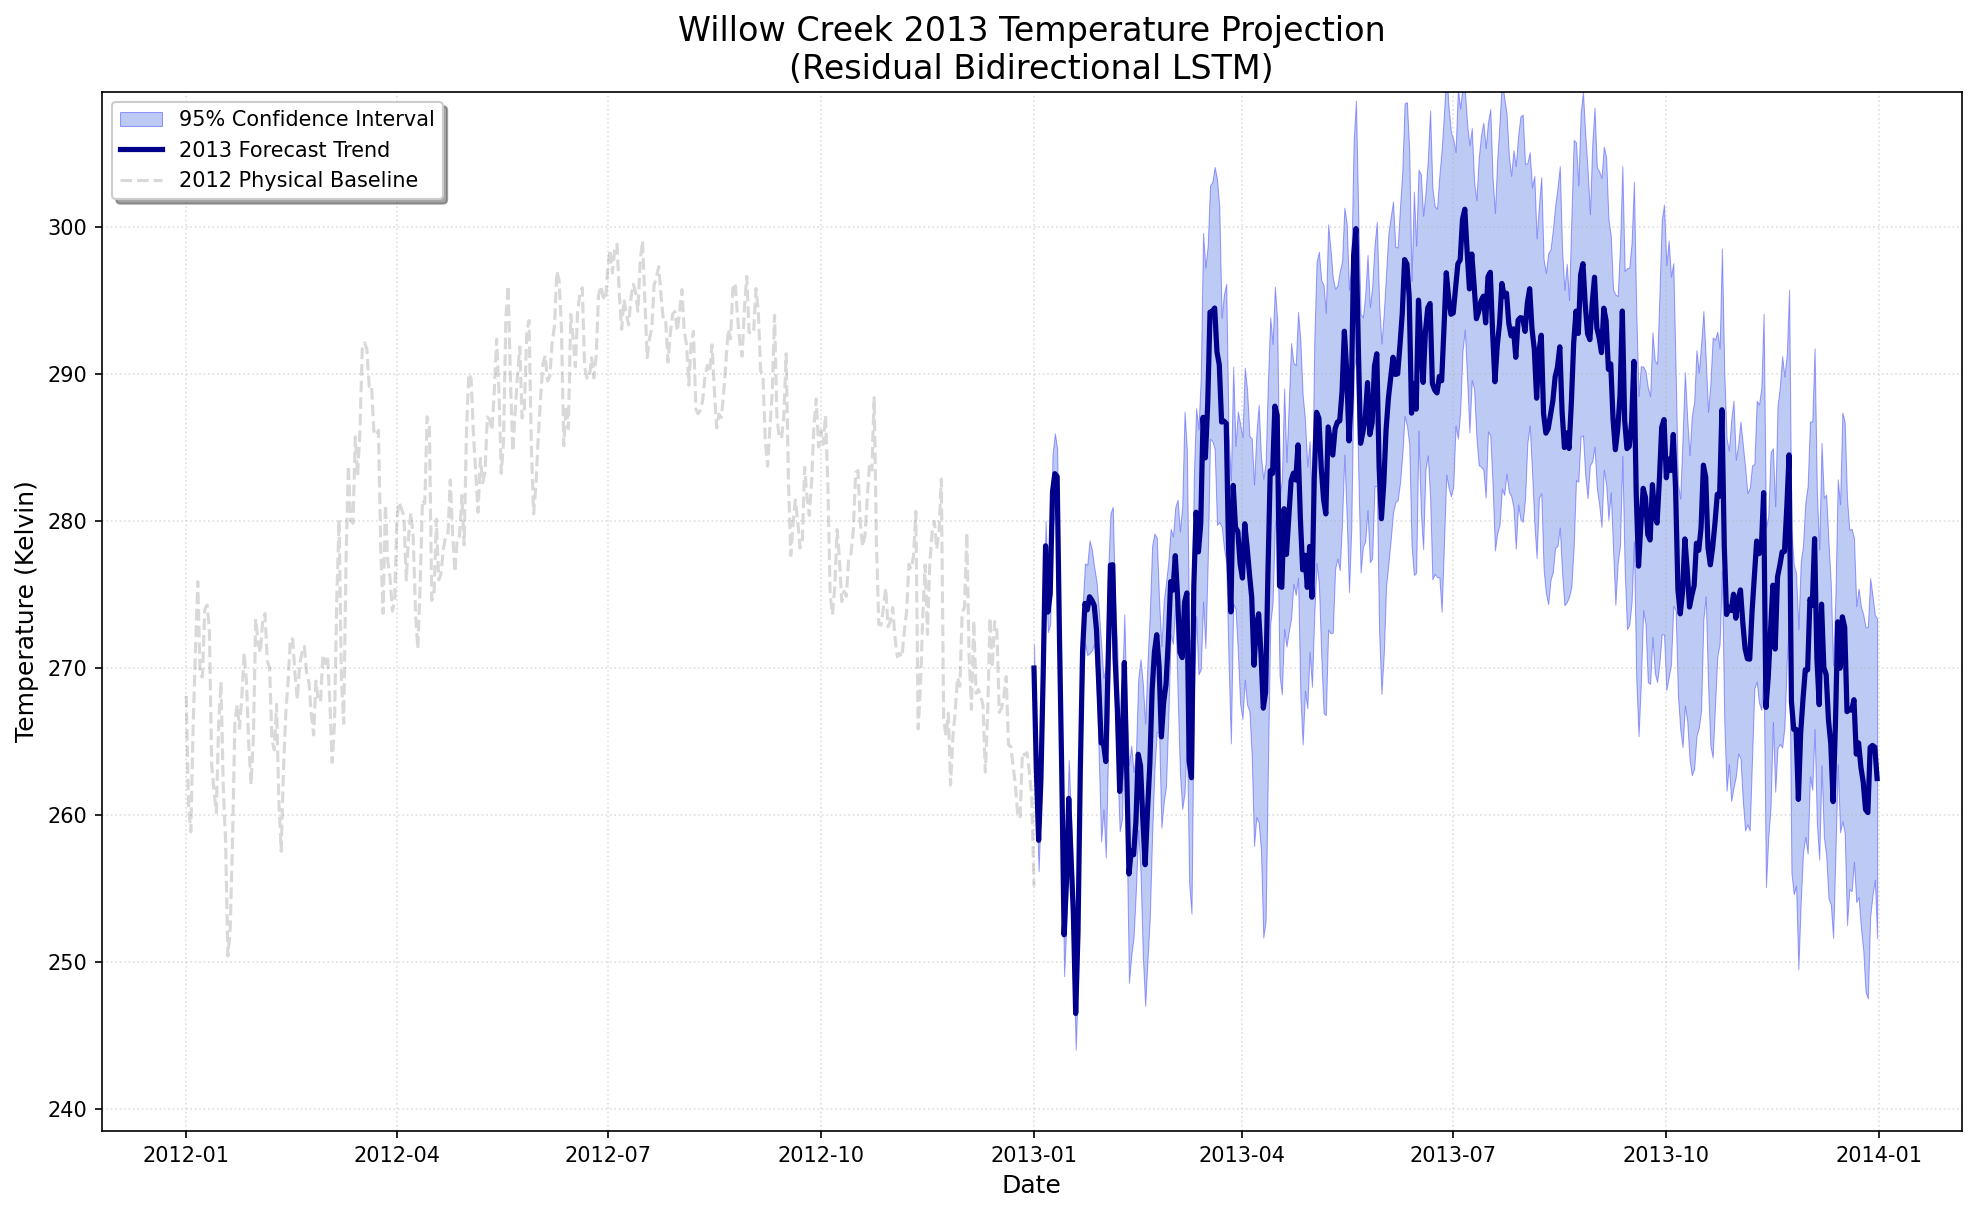


✅ SUCCESS: PROJECT EXPORTED
📁 Plot saved as:    willow_creek_2013_forecast.png
📁 Weights saved as: willow_creek_model_weights.pth
📁 Scaler saved as:  residual_scaler.pkl
📁 CSV saved as:     willow_creek_2013_results.csv
📡 Avg Uncertainty:  ±9.6902 K


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from sklearn.preprocessing import MinMaxScaler
import joblib
import calendar
import warnings
import os

# Auto-install tqdm if missing: %pip install tqdm
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, **kwargs): return iterable

warnings.filterwarnings("ignore")

# --- 1. CONFIGURATION & DEVICE ---
# 1a. SETUP DEVICE FOR M2 MAC
# Check for Metal (MPS), then CUDA, then fallback to CPU

FORCE_CPU = False

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using M2 GPU (MPS)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using NVIDIA GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")
    
# 1b. FORCE M2 CPU FOR ACCURACY
if FORCE_CPU:
    device = torch.device("cpu")
    print("Targeting M2 CPU (AMX) for maximum precision...")

FORECAST_YEAR = 2013
LOOKBACK = 365
STEP = 7
EPOCHS = 100
MC_SAMPLES = 30  # Increased for a high-quality, smooth confidence cloud

print(f"🚀 Initializing Willow Creek Climate Engine on: {device}")

# --- 2. DATA PREPROCESSING ---
print("📊 Processing Climate Data...")
# Load datasets (using standard WCr wildcard)
ds = xr.open_mfdataset("./ML_Data/WCr*")['air_temperature']
ds_daily = ds.resample(time='1D').mean()
df = pd.DataFrame(
    index=pd.to_datetime(ds_daily.time.values),
    data=ds_daily.squeeze().values, 
    columns=['airT']
).dropna()

# Residual Learning: Delta = Today - Same Day Last Year
df['last_year'] = df['airT'].shift(365)
df['delta'] = df['airT'] - df['last_year']
df = df.dropna()

# Setup Scaling
sc_delta = MinMaxScaler(feature_range=(-1, 1))
train_df = df['2011-01-01':'2012-12-31']
train_scaled = sc_delta.fit_transform(train_df[['delta']])

# Leap Year Check for Forecast Window
days_in_target = 366 if calendar.isleap(FORECAST_YEAR) else 365
# Extract 2012 baseline template
base_values = df['2012-01-01':'2012-12-31']['airT'].iloc[:days_in_target].values

def split_sequence(sequence, n_input, n_output):
    X, Y = [], []
    for i in range(len(sequence)-n_input-n_output+1):
        X.append(sequence[i:i+n_input, 0])
        Y.append(sequence[i+n_input:i+n_input+n_output, 0])
    return np.array(X), np.array(Y)

X_train, y_train = split_sequence(train_scaled, LOOKBACK, STEP)
X_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1).to(device)
y_t = torch.tensor(y_train, dtype=torch.float32).to(device)
train_loader = DataLoader(TensorDataset(X_t, y_t), batch_size=32, shuffle=True)

# --- 3. MODEL ARCHITECTURE ---
class ResidualLSTM(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=128, num_layers=3, output_dim=7):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, 
                            batch_first=True, dropout=0.4, bidirectional=True)
        self.dropout_layer = nn.Dropout(p=0.4) 
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout_layer(out[:, -1, :])
        return self.fc(out)

model = ResidualLSTM(output_dim=STEP).to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# --- 4. TRAINING LOOP ---
print(f"🧠 Training Model for {EPOCHS} Epochs...")
model.train()
pbar = tqdm(range(EPOCHS), desc="Training Progress")
for epoch in pbar:
    epoch_loss = 0
    for bx, by in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(bx), by)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    pbar.set_postfix({"MSE": f"{epoch_loss/len(train_loader):.6f}"})

# --- 5. MONTE CARLO INFERENCE ---
def run_mc_forecast(model, start_window, base_vals, target_days, iters):
    all_runs = []
    pbar_f = tqdm(range(iters), desc=f"Simulating {FORECAST_YEAR} Projections")
    
    # Force Dropout and LSTM randomization to stay active during eval
    model.eval()
    for m in model.modules():
        if isinstance(m, nn.Dropout) or isinstance(m, nn.LSTM):
            m.train()
            
    for _ in pbar_f:
        current_window = start_window.copy()
        pred_deltas = []
        with torch.no_grad():
            for _ in range(0, target_days, STEP):
                in_t = torch.tensor(current_window[-LOOKBACK:], dtype=torch.float32).view(1, LOOKBACK, 1).to(device)
                pred = model(in_t).cpu().numpy().flatten()
                pred_deltas.extend(pred)
                for p in pred: current_window.append([p])
        
        unscaled = sc_delta.inverse_transform(np.array(pred_deltas[:target_days]).reshape(-1, 1)).flatten()
        all_runs.append(base_vals + unscaled)
    return np.array(all_runs)

print("🔮 Generating Probabilistic Forecast...")
start_win = train_scaled[-LOOKBACK:].tolist()
mc_results = run_mc_forecast(model, start_win, base_values, days_in_target, MC_SAMPLES)

# --- 6. VISUALIZATION & EXPORT ---
print("🎨 Finalizing Plots and Saving Data...")
mean_f = np.mean(mc_results, axis=0)
std_f = np.std(mc_results, axis=0)
idx = pd.date_range(start=f'{FORECAST_YEAR}-01-01', periods=days_in_target)

# Calculation for Confidence Interval
lower_95 = mean_f - (1.96 * std_f)
upper_95 = mean_f + (1.96 * std_f)

# Create High-Res Plot
plt.figure(figsize=(16, 9), dpi=150)

# Confidence Cloud (95% CI)
plt.fill_between(idx, lower_95, upper_95, color='royalblue', alpha=0.35, 
                 edgecolor='blue', linewidth=0.5, label='95% Confidence Interval')

# Forecast Mean
plt.plot(idx, mean_f, color='darkblue', lw=2.5, label=f'{FORECAST_YEAR} Forecast Trend')

# Baseline (Previous Year)
plt.plot(df['2012-01-01':].index, df['2012-01-01':]['airT'], 
         color='black', alpha=0.15, linestyle='--', label='2012 Physical Baseline')

# Formatting
plt.title(f"Willow Creek {FORECAST_YEAR} Temperature Projection\n(Residual Bidirectional LSTM)", fontsize=16)
plt.ylabel("Temperature (Kelvin)", fontsize=12)
plt.xlabel("Date", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.ylim(mean_f.min() - 8, mean_f.max() + 8)

# SAVE PLOT TO FILE
plot_filename = f"willow_creek_{FORECAST_YEAR}_forecast.png"
plt.savefig(plot_filename, bbox_inches='tight')
plt.show()

# --- 7. SAVING WEIGHTS AND SCALER ---
torch.save(model.state_dict(), 'willow_creek_model_weights.pth')
joblib.dump(sc_delta, 'residual_scaler.pkl')

# Save Data to CSV
results_df = pd.DataFrame({
    'date': idx,
    'mean_temp_K': mean_f,
    'std_dev_K': std_f,
    'lower_95_K': lower_95,
    'upper_95_K': upper_95
}).set_index('date')
results_df.to_csv(f'willow_creek_{FORECAST_YEAR}_results.csv')

print("\n" + "="*40)
print(f"✅ SUCCESS: PROJECT EXPORTED")
print("="*40)
print(f"📁 Plot saved as:    {plot_filename}")
print(f"📁 Weights saved as: willow_creek_model_weights.pth")
print(f"📁 Scaler saved as:  residual_scaler.pkl")
print(f"📁 CSV saved as:     willow_creek_{FORECAST_YEAR}_results.csv")
print(f"📡 Avg Uncertainty:  ±{std_f.mean()*1.96:.4f} K")
print("="*40)


📂 Loading Pre-trained Model: willow_creek_model_weights.pth
✅ Weights and Scaler Loaded Successfully.
🔮 Projecting 2014...


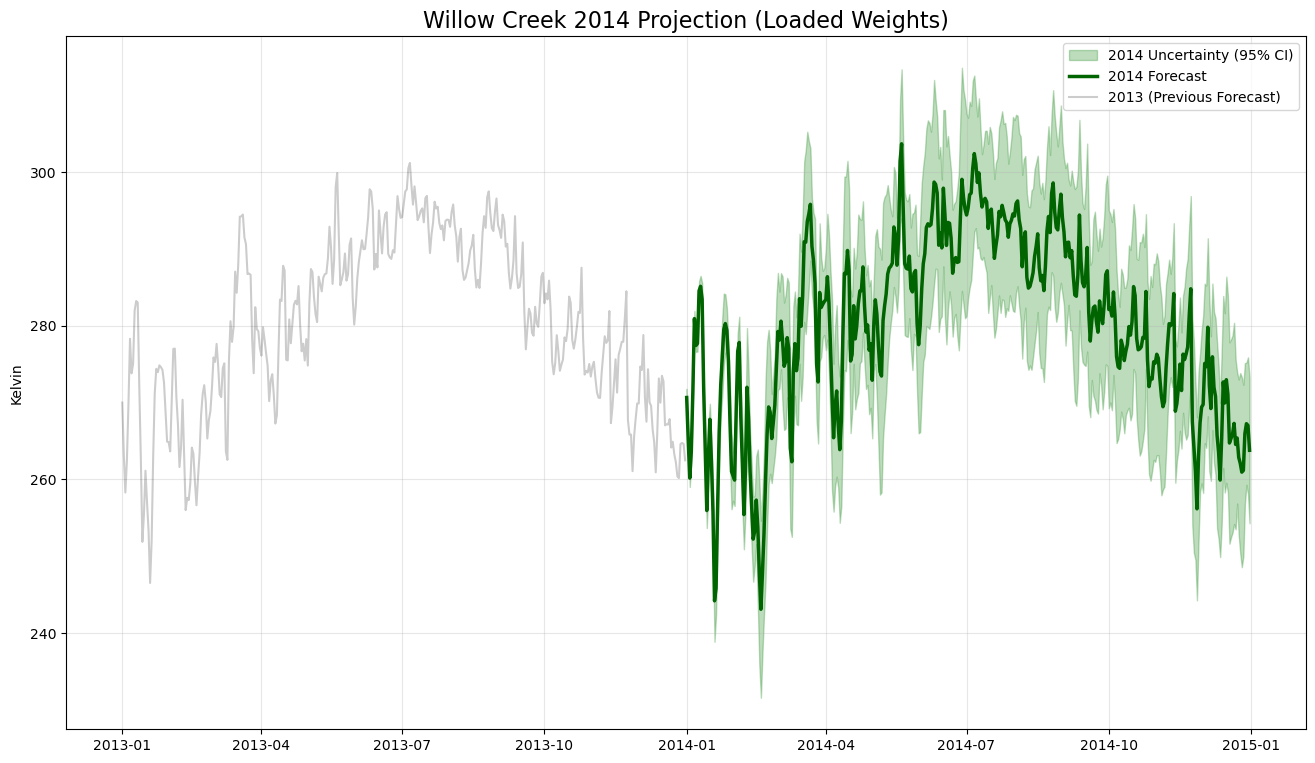

✅ 2014 Forecast Complete. Saved to: forecast_2014_reloaded.png


In [8]:
# If training is saved, can use this to extend forecast

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import calendar
import warnings

warnings.filterwarnings("ignore")

# --- 1. CONFIGURATION ---
device = torch.device("mps")
LOAD_WEIGHTS = 'willow_creek_model_weights.pth'
LOAD_SCALER = 'residual_scaler.pkl'
NEW_FORECAST_YEAR = 2014
LOOKBACK = 365
STEP = 7
MC_SAMPLES = 30 

# --- 2. DEFINE ARCHITECTURE (Must match training exactly) ---
class ResidualLSTM(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=128, num_layers=3, output_dim=7):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, 
                            batch_first=True, dropout=0.4, bidirectional=True)
        self.dropout_layer = nn.Dropout(p=0.4) 
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout_layer(out[:, -1, :])
        return self.fc(out)

# --- 3. LOAD MODEL & SCALER ---
print(f"📂 Loading Pre-trained Model: {LOAD_WEIGHTS}")
model = ResidualLSTM(output_dim=STEP).to(device)
model.load_state_dict(torch.load(LOAD_WEIGHTS))
sc_delta = joblib.load(LOAD_SCALER)
print("✅ Weights and Scaler Loaded Successfully.")

# --- 4. PREPARE SEED DATA (2013) ---
# Note: This assumes your 'results_df' or original 'df' from 2013 is in memory.
# If starting fresh, load your 2013 CSV/Data here:
# df_2013 = pd.read_csv('willow_creek_2013_results.csv', index_col='date', parse_dates=True)

# For this script, we'll use the 'mean_temp_K' from your 2013 forecast as the new baseline
# This allows for "Chain Forecasting"
try:
    # Attempt to grab the 2013 results from the previous run
    base_2013_values = mean_f 
    # We calculate the last year's deltas to seed the 2014 run
    # (2013 Results - 2012 Baseline)
    seed_deltas = (mean_f - base_values)
    seed_window_scaled = sc_delta.transform(seed_deltas.reshape(-1, 1))
except NameError:
    print("❌ Error: 2013 result data not found in memory. Please ensure the previous cell was run.")

# --- 5. RUN 2014 PROJECTION ---
def run_reloaded_forecast(model, start_window, base_vals, iters):
    target_days = 366 if calendar.isleap(NEW_FORECAST_YEAR) else 365
    all_runs = []
    
    model.eval()
    for m in model.modules():
        if isinstance(m, nn.Dropout) or isinstance(m, nn.LSTM):
            m.train() # Keep MC-Dropout Active
            
    print(f"🔮 Projecting {NEW_FORECAST_YEAR}...")
    for _ in range(iters):
        win = start_window.copy()
        pred_deltas = []
        with torch.no_grad():
            for _ in range(0, target_days, STEP):
                in_t = torch.tensor(win[-LOOKBACK:], dtype=torch.float32).view(1, LOOKBACK, 1).to(device)
                pred = model(in_t).cpu().numpy().flatten()
                pred_deltas.extend(pred)
                for p in pred: win.append([p])
        
        unscaled = sc_delta.inverse_transform(np.array(pred_deltas[:target_days]).reshape(-1, 1)).flatten()
        all_runs.append(base_vals[:target_days] + unscaled)
    return np.array(all_runs)

# Execute
mc_2014 = run_reloaded_forecast(model, seed_window_scaled.tolist(), base_2013_values, MC_SAMPLES)

# --- 6. PLOT & SAVE 2014 ---
mean_2014 = np.mean(mc_2014, axis=0)
std_2014 = np.std(mc_2014, axis=0)
idx_2014 = pd.date_range(start=f'{NEW_FORECAST_YEAR}-01-01', periods=len(mean_2014))

plt.figure(figsize=(16, 9))
plt.fill_between(idx_2014, mean_2014 - (1.96 * std_2014), mean_2014 + (1.96 * std_2014), 
                 color='forestgreen', alpha=0.3, label='2014 Uncertainty (95% CI)')
plt.plot(idx_2014, mean_2014, color='darkgreen', lw=2.5, label=f'{NEW_FORECAST_YEAR} Forecast')
plt.plot(idx, mean_f, color='black', alpha=0.2, label='2013 (Previous Forecast)')

plt.title(f"Willow Creek {NEW_FORECAST_YEAR} Projection (Loaded Weights)", fontsize=16)
plt.ylabel("Kelvin")
plt.legend()
plt.grid(True, alpha=0.3)

# Save the new plot
plt.savefig(f"forecast_{NEW_FORECAST_YEAR}_reloaded.png", bbox_inches='tight')
plt.show()

print(f"✅ 2014 Forecast Complete. Saved to: forecast_{NEW_FORECAST_YEAR}_reloaded.png")

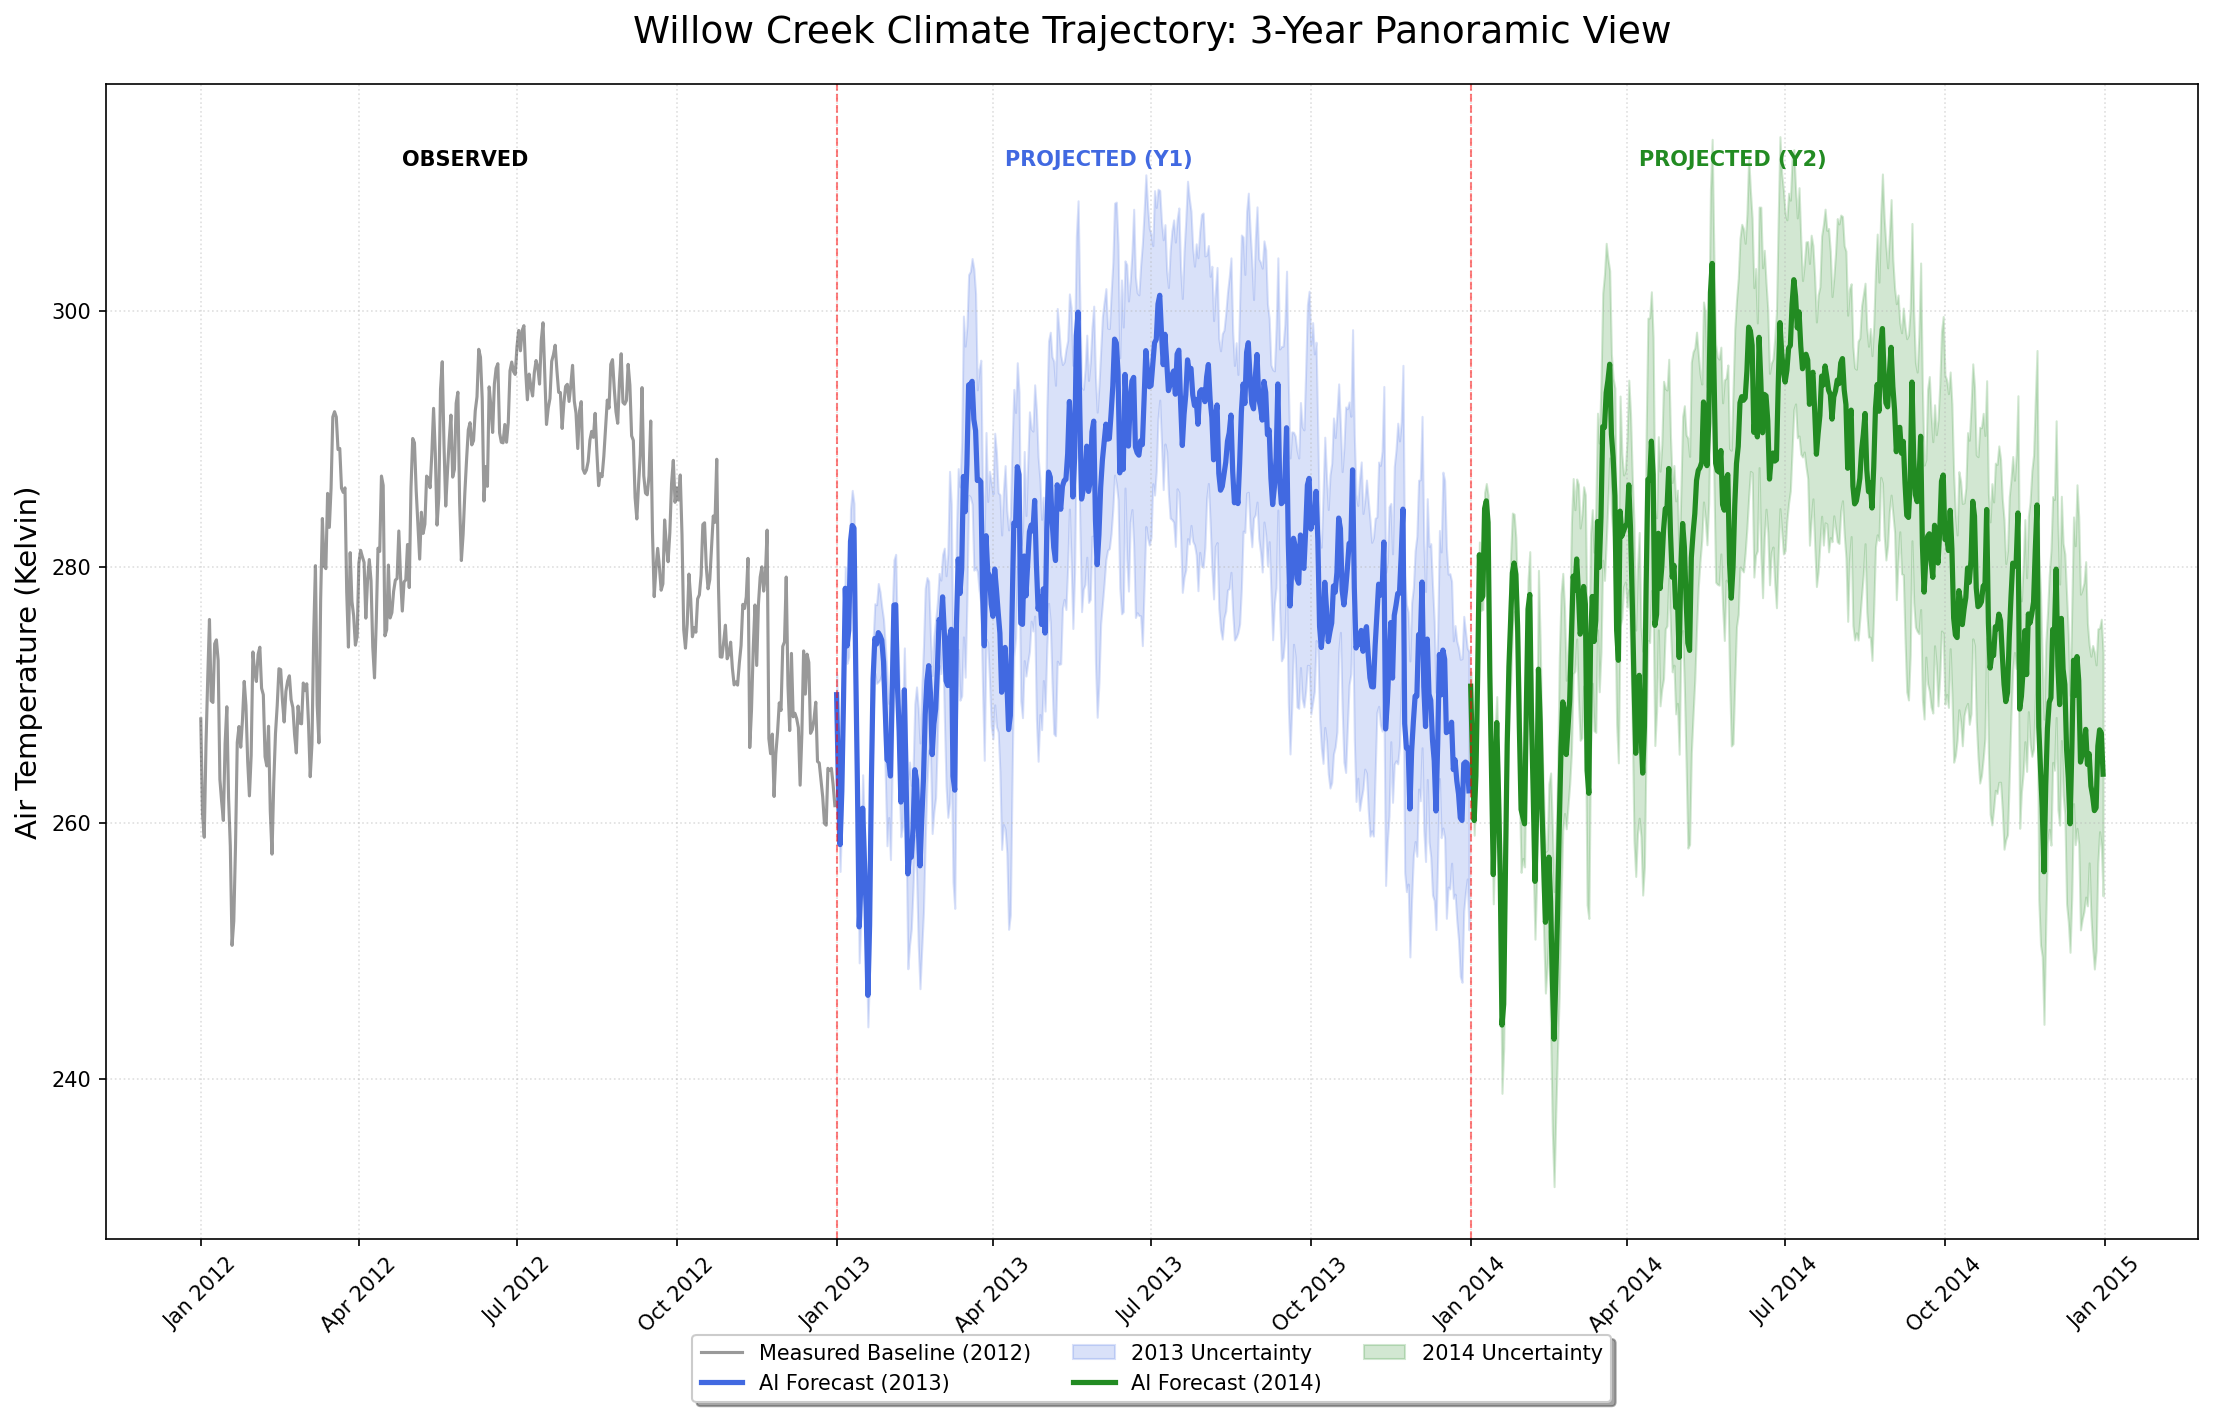

✅ Multi-Year Panorama saved as: willow_creek_3year_panorama.png


In [9]:
#Plotting it all together

import matplotlib.dates as mdates

# --- 1. STITCH DATASETS TOGETHER ---
# Historical 2012
idx_2012 = df['2012-01-01':'2012-12-31'].index
vals_2012 = df['2012-01-01':'2012-12-31']['airT'].values

# Combined Timeline
full_idx = idx_2012.append(idx).append(idx_2014)
full_mean = np.concatenate([vals_2012, mean_f, mean_2014])

# --- 2. CREATE PANORAMIC VISUALIZATION ---
plt.figure(figsize=(18, 10), dpi=150)

# A. Historical Baseline (2012)
plt.plot(idx_2012, vals_2012, color='black', lw=1.5, alpha=0.4, label='Measured Baseline (2012)')

# B. 2013 Forecast & Confidence
plt.plot(idx, mean_f, color='royalblue', lw=2.5, label='AI Forecast (2013)')
plt.fill_between(idx, lower_95, upper_95, color='royalblue', alpha=0.2, label='2013 Uncertainty')

# C. 2014 Forecast & Confidence
plt.plot(idx_2014, mean_2014, color='forestgreen', lw=2.5, label='AI Forecast (2014)')
plt.fill_between(idx_2014, mean_2014 - (1.96 * std_2014), mean_2014 + (1.96 * std_2014), 
                 color='forestgreen', alpha=0.2, label='2014 Uncertainty')

# D. Vertical Dividers for Years
plt.axvline(pd.Timestamp('2013-01-01'), color='red', linestyle='--', alpha=0.5, lw=1)
plt.axvline(pd.Timestamp('2014-01-01'), color='red', linestyle='--', alpha=0.5, lw=1)

# Text Annotations
plt.text(pd.Timestamp('2012-06-01'), plt.ylim()[1]*0.98, 'OBSERVED', color='black', fontweight='bold', ha='center')
plt.text(pd.Timestamp('2013-06-01'), plt.ylim()[1]*0.98, 'PROJECTED (Y1)', color='royalblue', fontweight='bold', ha='center')
plt.text(pd.Timestamp('2014-06-01'), plt.ylim()[1]*0.98, 'PROJECTED (Y2)', color='forestgreen', fontweight='bold', ha='center')

# --- 3. FORMATTING ---
plt.title("Willow Creek Climate Trajectory: 3-Year Panoramic View", fontsize=18, pad=20)
plt.ylabel("Air Temperature (Kelvin)", fontsize=14)
plt.xlabel("Timeline", fontsize=14)

# Better X-Axis Ticks
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True, shadow=True)

# SAVE THE PANORAMA
plt.savefig("willow_creek_3year_panorama.png", bbox_inches='tight')
plt.show()

print("✅ Multi-Year Panorama saved as: willow_creek_3year_panorama.png")